<a href="https://colab.research.google.com/github/varshabantu/Data-Science-Tasks/blob/main/Youtube_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load dataset and read rows
df = pd.read_csv("https://github.com/Taj1920/Data_Analysis/raw/refs/heads/main/Youtube_analysis/YOUTUBE%20CHANNELS%20DATASET.csv")
df.head()

,Ranking,Username,Subscribers,Uploads,Views,Country
0,1.0,MrBeast,336M,838,"66,853,633,536",US
1,2.0,T-Series,281M,"22,313","277,242,795,553",IN
2,3.0,Cocomelon-Nursery Rhymes,186M,1370,"194,361,752,276",US
3,4.0,Youtube Movies,185M,0,0,NaN
4,5.0,Set India,180M,"148,727","172,709,029,653",IN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Ranking      100 non-null    float64
 1   Username     100 non-null    object 
 2   Subscribers  100 non-null    object 
 3   Uploads      100 non-null    object 
 4   Views        100 non-null    object 
 5   Country      94 non-null     object 
dtypes: float64(1), object(5)
memory usage: 4.9+ KB


In [5]:
df.isnull().sum()

,0
Ranking,1
Username,1
Subscribers,1
Uploads,1
Views,1
Country,7


In [7]:
#Drop all nan values
df.dropna(inplace=True)
df.reset_index(inplace=True)
df.drop('index',axis=1,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Ranking      94 non-null     float64
 1   Username     94 non-null     object 
 2   Subscribers  94 non-null     object 
 3   Uploads      94 non-null     object 
 4   Views        94 non-null     object 
 5   Country      94 non-null     object 
dtypes: float64(1), object(5)
memory usage: 4.5+ KB


In [8]:
#We have to change datatype of ranking column
df["Ranking"] = df["Ranking"].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Ranking      94 non-null     int64 
 1   Username     94 non-null     object
 2   Subscribers  94 non-null     object
 3   Uploads      94 non-null     object
 4   Views        94 non-null     object
 5   Country      94 non-null     object
dtypes: int64(1), object(5)
memory usage: 4.5+ KB


In [10]:
#Remove unwanted data and convert subscribers column into float datatype
# df["Subscribers"] = df["Subscribers"].str.replace("subscribers", "")
# df["Subscribers"]
df['Subscribers']=df['Subscribers'].str.strip('M')
df['Subscribers']=df['Subscribers'].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Ranking      94 non-null     int64  
 1   Username     94 non-null     object 
 2   Subscribers  94 non-null     float64
 3   Uploads      94 non-null     object 
 4   Views        94 non-null     object 
 5   Country      94 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.5+ KB


In [11]:
#Replacing ',' to '' and converting uploads and views col into int data type

df['Uploads']=df['Uploads'].str.replace(',','')
df['Uploads']=df['Uploads'].astype(int)

df['Views']=df['Views'].str.replace(',','')
df['Views']=df['Views'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Ranking      94 non-null     int64  
 1   Username     94 non-null     object 
 2   Subscribers  94 non-null     float64
 3   Uploads      94 non-null     int64  
 4   Views        94 non-null     int64  
 5   Country      94 non-null     object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.5+ KB


In [12]:
df["Country"].unique()

array(['US', 'IN', 'JP', 'KR', 'CA', 'PT', 'AE', 'BR', 'AR', 'PK', 'MX',
       'IT', 'GB', 'RU', 'ES', 'ID', 'CL', 'PH', 'TR', 'PR', 'SV', 'CO',
       'NO'], dtype=object)

# VISUALIZATION

In [14]:
def label(a):
    for i in a.containers:
        a.bar_label(i,label_type="center",rotation=90)

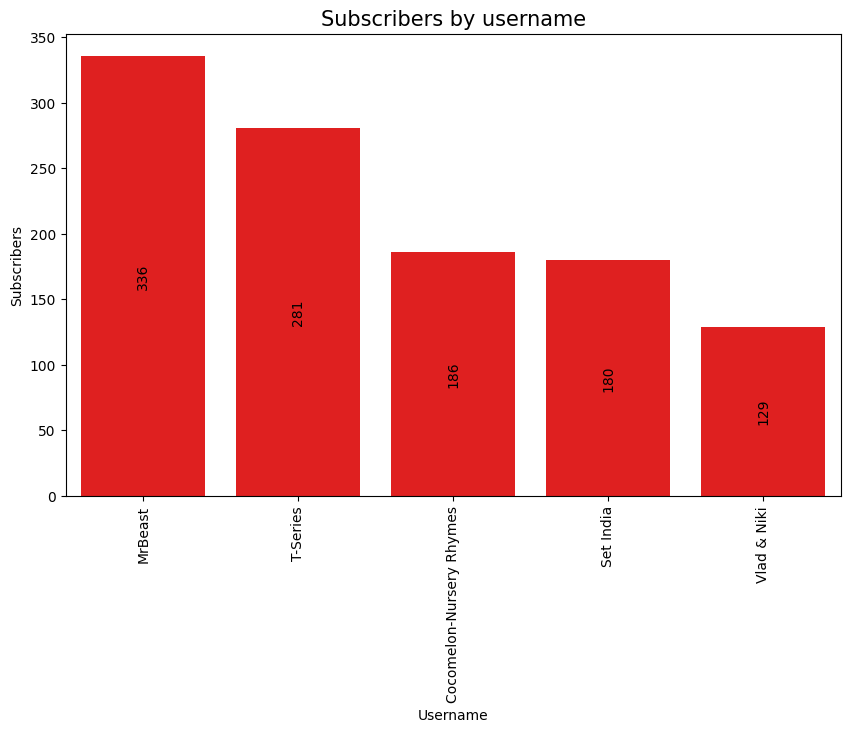

In [16]:
plt.figure(figsize=(10,6))
a=sns.barplot(x='Username',y='Subscribers',data=df.sort_values(by='Subscribers',ascending=False).iloc[:5,:],color='red')
label(a)
plt.title('Subscribers by username',fontsize=15)
plt.xticks(rotation=90)
plt.show()

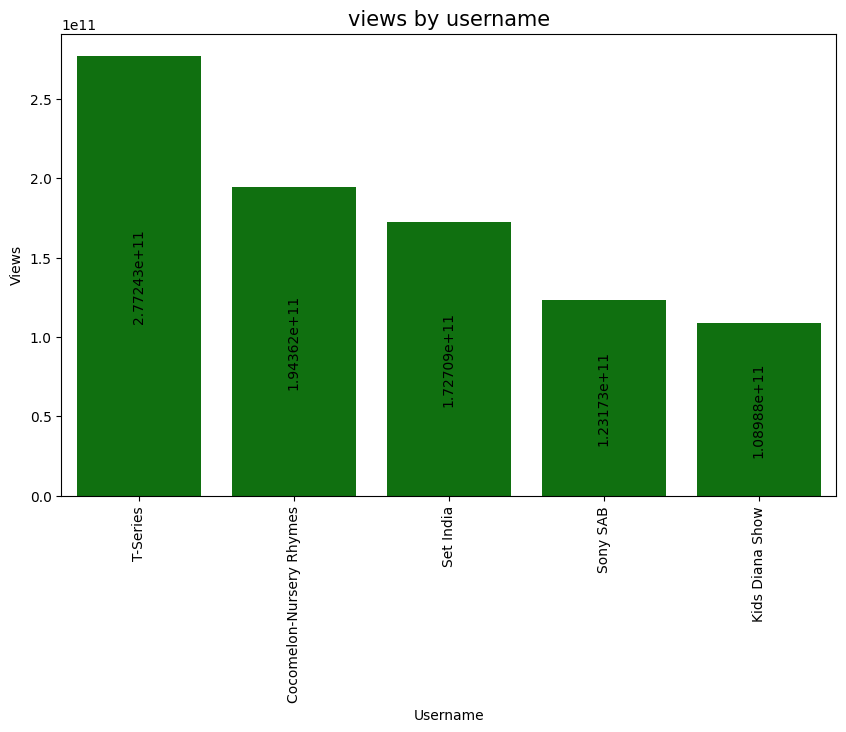

In [31]:
plt.figure(figsize=(10,6))
a=sns.barplot(x='Username',y='Views',data=df.sort_values(by='Views',ascending=False).iloc[:5,:],color='green')
label(a)
plt.title('views by username',fontsize=15)
plt.xticks(rotation=90)
plt.show()

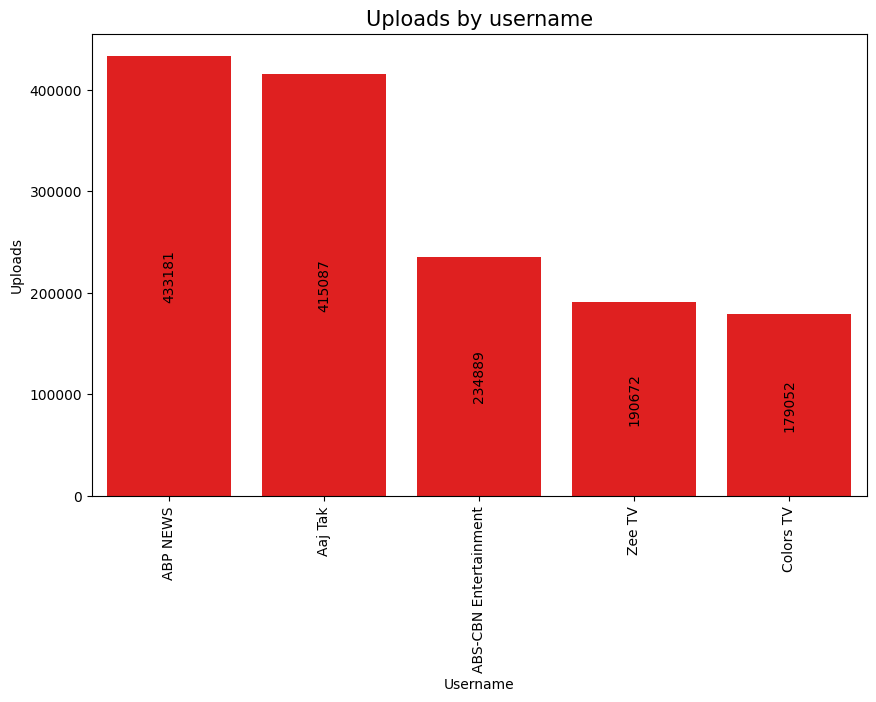

In [18]:
plt.figure(figsize=(10,6))
a=sns.barplot(x='Username',y='Uploads',data=df.sort_values(by='Uploads',ascending=False).iloc[:5,:],color='red')
plt.title('Uploads by username',fontsize=15)
label(a)
plt.xticks(rotation=90)
plt.show()

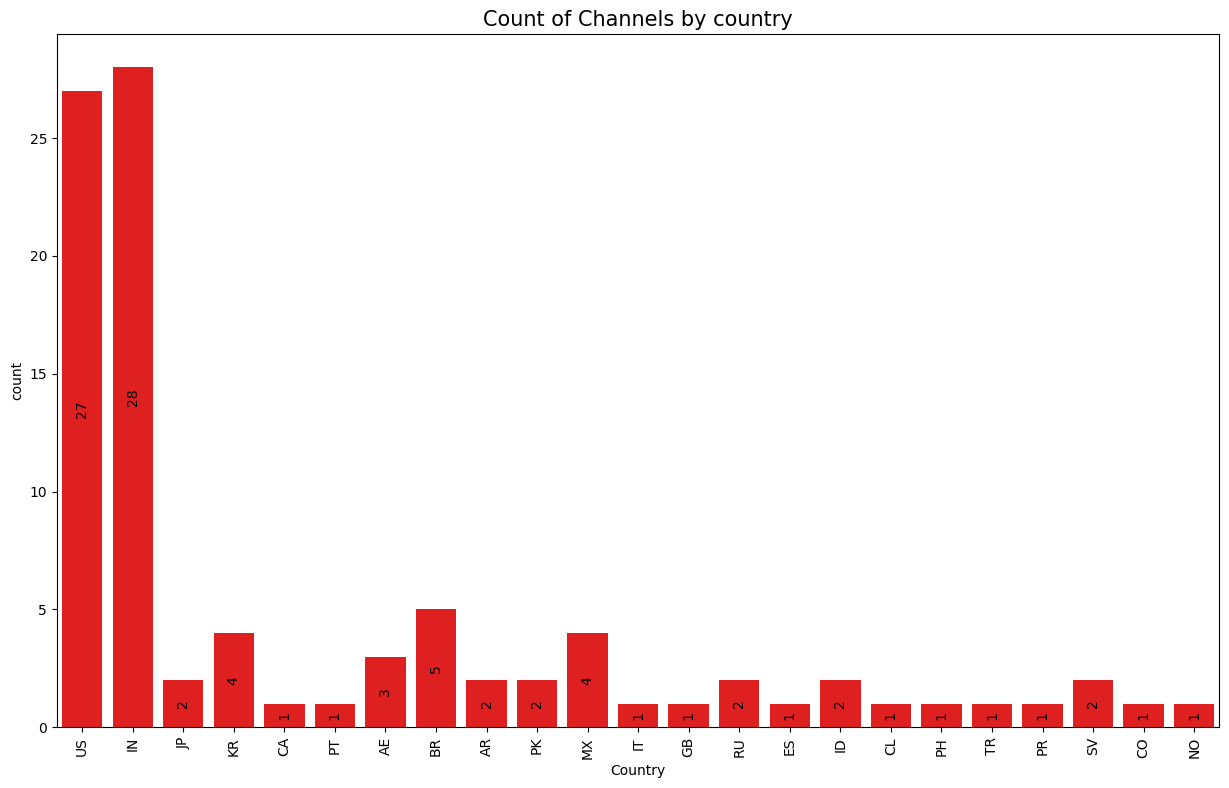

In [19]:
plt.figure(figsize=(15,9))
a=sns.countplot(x='Country',data=df,color='red')
label(a)
plt.title('Count of Channels by country',fontsize=15)
plt.xticks(rotation=90)
plt.show()

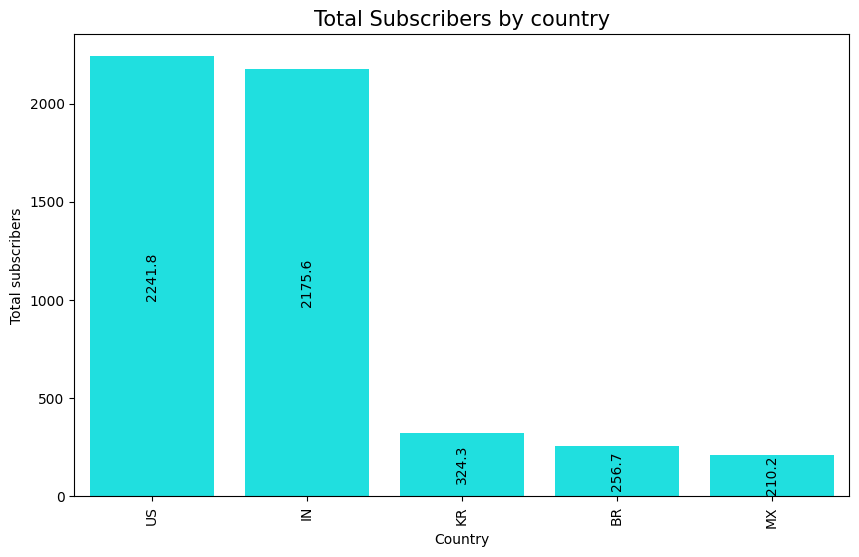

In [30]:
df1=df.pivot_table(values=['Subscribers','Uploads','Views'],index='Country',aggfunc=['sum'])
plt.figure(figsize=(10,6))
a=sns.barplot(x='Country',y=('sum', 'Subscribers'),data=df1.sort_values(('sum', 'Subscribers'),ascending=False).iloc[:5,:],color='aqua')
label(a)
plt.title('Total Subscribers by country',fontsize=15)
plt.ylabel('Total subscribers')
plt.xticks(rotation=90)
plt.show()

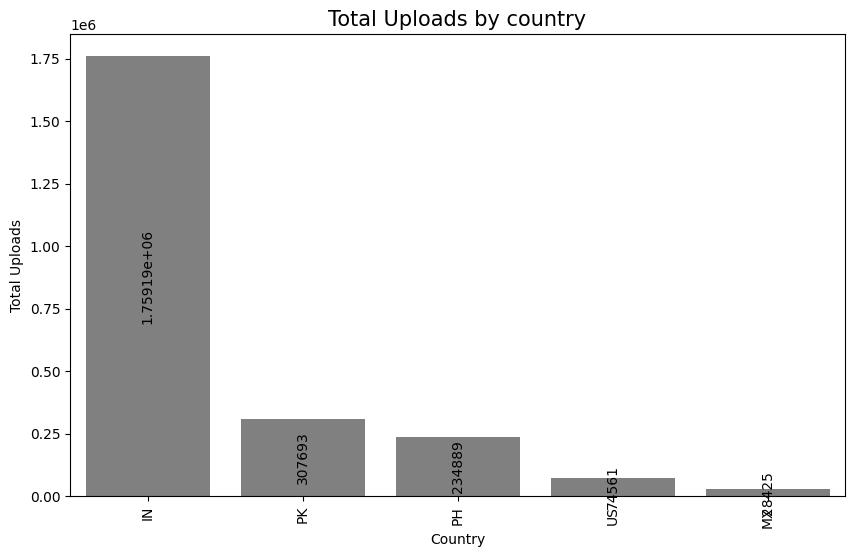

In [27]:
plt.figure(figsize=(10,6))
a=sns.barplot(x='Country',y=('sum', 'Uploads'),data=df1.sort_values(('sum', 'Uploads'),ascending=False).iloc[:5,:],color='gray')
label(a)
plt.title('Total Uploads by country',fontsize=15)
plt.ylabel('Total Uploads')
plt.xticks(rotation=90)
plt.show()

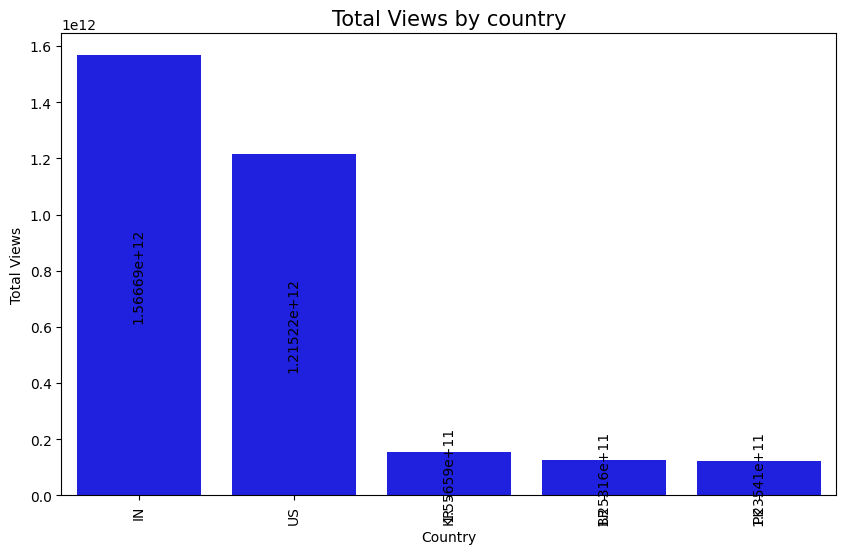

In [23]:
plt.figure(figsize=(10,6))
a=sns.barplot(x='Country',y=('sum', 'Views'),data=df1.sort_values(('sum', 'Views'),ascending=False).iloc[:5,:],color='blue')
label(a)
plt.title('Total Views by country',fontsize=15)
plt.ylabel('Total Views')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Conclusion:
# By analysing above data i conclude that
# 1.Youtube channels such as T-Series and Cocomelon-Nursery are having highest Subscribers and views compared to other channels.
# 2. Youtube channels from India and USA are having highest Subscribers and views compared to other channels.
